# B2B Coordination Platform — Illustrative Simulation

**Purpose:** Make the conceptual framework tangible; check internal consistency.  
**Not predictive** — parameters and network are stylised but structurally informed by European aviation.

## Design parameters varied
| Dimension | Options |
|---|---|
| Participation model (§5.2.1) | NWC-only / +Regionals / +LCCs |
| Coordination scope (§5.2.2–3) | Alliance-only / All-platform |
| Active hubs (data architecture §5.2.4) | Subset of {FRA, AMS, CDG, MAD, MUC} |
| Anchor NWCs (feasibility C1) | 1 / 2 / 4 of 4 |

We run a **curated subset** of 8 scenarios that isolate each parameter's effect.

**Long-haul layer:** NWCs operate intercontinental routes from their hubs (e.g., FRA–JFK, MAD–GRU). LCCs and regional carriers stay intra-European. The platform's primary commercial use case is therefore **feeder-to-longhaul self-connection**: a passenger originating from a European spoke joins an NWC long-haul flight via a hub. Tracked as a distinct metric below.

In [1]:
import random
import itertools
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
from collections import defaultdict
from pathlib import Path

random.seed(42)
np.random.seed(42)

FIGURES = Path('figures')
FIGURES.mkdir(exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


---
## Part 1 — Network construction

In [2]:
# ── 1.1  Airport master data ────────────────────────────────────────────────
# (lon, lat) are approximate; used only for layout / distance proxy.

HUBS = {
    'FRA': (8.57,  50.03),
    'AMS': (4.76,  52.31),
    'CDG': (2.55,  49.01),
    'MAD': (-3.57, 40.47),
    'MUC': (11.79, 48.35),
}

# ~50 European spoke airports
SPOKES = {
    # Iberian peninsula
    'BCN': (-2.07, 41.30), 'LIS': (-9.14, 38.78), 'SVQ': (-5.90, 37.42),
    'VLC': (-0.48, 39.49), 'BIO': (-2.91, 43.30), 'AGP': (-4.50, 36.67),
    # France
    'LYS': (5.09,  45.72), 'MRS': (5.22,  43.44), 'NCE': (7.21,  43.66),
    'BOD': (-0.72, 44.83), 'TLS': (1.37,  43.63), 'NTE': (-1.60, 47.16),
    # British Isles
    'LHR': (-0.46, 51.48), 'MAN': (-2.27, 53.35), 'DUB': (-6.27, 53.43),
    'EDI': (-3.37, 55.95), 'BRS': (-2.72, 51.38),
    # Benelux / Germany / Alps
    'BRU': (4.48,  50.90), 'DUS': (6.77,  51.29), 'HAM': (10.00, 53.63),
    'BER': (13.40, 52.55), 'STR': (7.63,  48.54), 'NUE': (11.07, 49.50),
    'VIE': (16.57, 48.11), 'ZRH': (8.55,  47.46), 'GVA': (6.10,  46.24),
    'PRG': (14.26, 50.10),
    # Scandinavia / Baltics
    'CPH': (12.66, 55.62), 'ARN': (17.92, 59.65), 'OSL': (11.10, 60.20),
    'HEL': (24.96, 60.32), 'RIG': (23.97, 56.92), 'TLL': (24.83, 59.41),
    # Italy
    'FCO': (12.25, 41.80), 'MXP': (8.72,  45.63), 'VCE': (12.35, 45.51),
    'NAP': (14.29, 40.89), 'PMO': (13.09, 38.18),
    # Eastern Europe / Balkans
    'WAW': (20.97, 52.17), 'BUD': (19.26, 47.44), 'OTP': (26.10, 44.57),
    'SOF': (23.41, 42.70), 'ATH': (23.94, 37.94), 'IST': (28.82, 41.28),
    # Canaries / North Africa
    'LPA': (-15.39, 27.93), 'TFN': (-16.57, 28.48),
    'CMN': (-7.59, 33.37),  'RAK': (-8.03, 31.61),
}

# Long-haul destinations served only by NWCs from their hubs
LONGHAUL = {
    # North America
    'JFK': (-73.78,  40.64), 'EWR': (-74.17, 40.69),
    'ORD': (-87.90,  41.98), 'IAD': (-77.46, 38.95),
    'IAH': (-95.34,  29.98), 'LAX': (-118.41, 33.94),
    'MIA': (-80.29,  25.79), 'MEX': (-99.07, 19.44),
    # South America
    'GRU': (-46.48, -23.43), 'GIG': (-43.25, -22.81),
    'EZE': (-58.54, -34.82), 'LIM': (-77.11, -12.02),
    'BOG': (-74.15,   4.70),
    # Asia
    'NRT': (140.39,  35.77), 'PVG': (121.81, 31.14),
    'BKK': (100.75,  13.69),
    # Africa
    'LOS': (3.32,     6.58), 'JNB': (28.24, -26.13),
}

ALL_AIRPORTS = {**HUBS, **SPOKES, **LONGHAUL}
print(f'Airports: {len(HUBS)} hubs + {len(SPOKES)} EU spokes + {len(LONGHAUL)} long-haul '
      f'= {len(ALL_AIRPORTS)} total')

Airports: 5 hubs + 48 EU spokes + 18 long-haul = 71 total


In [3]:
# ── 1.2  Carrier definitions ─────────────────────────────────────────────────

NWC_HUBS = {
    'LH':  ['FRA', 'MUC'],
    'KL':  ['AMS'],
    'AF':  ['CDG'],
    'IB':  ['MAD'],
}

ALLIANCE = {
    'LH': 'Star', 'KL': 'SkyTeam', 'AF': 'SkyTeam', 'IB': 'oneworld',
    'FR': None,   'U2': None,       'VY': None,
    'OE': None,   'RR': None,
}

CARRIER_TYPE = {
    'LH': 'NWC', 'KL': 'NWC', 'AF': 'NWC', 'IB': 'NWC',
    'FR': 'LCC', 'U2': 'LCC', 'VY': 'LCC',
    'OE': 'REG', 'RR': 'REG',
}

HUB_MCT = {'FRA': 45, 'AMS': 40, 'CDG': 60, 'MAD': 50, 'MUC': 45}

print('Carrier metadata defined.')

Carrier metadata defined.


In [4]:
# ── 1.3  Route construction helpers ──────────────────────────────────────────

def approx_distance(a, b):
    """Euclidean proxy for geographic distance (degrees)."""
    lon1, lat1 = ALL_AIRPORTS[a]
    lon2, lat2 = ALL_AIRPORTS[b]
    return ((lon2-lon1)**2 + (lat2-lat1)**2)**0.5


def add_route(G, src, dst, carrier, freq, turnaround_min=None):
    """Add a directed edge (and its return) with metadata."""
    for u, v in [(src, dst), (dst, src)]:
        G.add_edge(u, v,
                   carrier=carrier,
                   carrier_type=CARRIER_TYPE[carrier],
                   alliance=ALLIANCE[carrier],
                   freq=freq,
                   duration=int(40 + 6 * approx_distance(u, v)))


def build_network():
    G = nx.MultiDiGraph()
    for ap, pos in ALL_AIRPORTS.items():
        G.add_node(ap, pos=pos,
                   is_hub=(ap in HUBS),
                   is_longhaul=(ap in LONGHAUL),
                   hub_mct=HUB_MCT.get(ap, None))
    return G

In [5]:
# ── 1.4  Network-carrier intra-European spoke assignments ────────────────────

LH_SPOKES = [
    ('FRA','HAM',6), ('FRA','BER',6), ('FRA','DUS',5), ('FRA','MAN',4),
    ('FRA','LHR',5), ('FRA','VIE',4), ('FRA','PRG',4), ('FRA','WAW',3),
    ('FRA','FCO',4), ('FRA','ATH',3), ('FRA','IST',3), ('FRA','ZRH',5),
    ('MUC','VIE',6), ('MUC','ZRH',5), ('MUC','FCO',4), ('MUC','MXP',4),
    ('MUC','PRG',4), ('MUC','BUD',3), ('MUC','ATH',3), ('MUC','LHR',4),
    ('MUC','BER',5), ('MUC','HAM',5), ('MUC','CPH',3), ('MUC','ARN',2),
]

KL_SPOKES = [
    ('AMS','LHR',6), ('AMS','MAN',4), ('AMS','DUB',4), ('AMS','CPH',4),
    ('AMS','OSL',3), ('AMS','ARN',3), ('AMS','HEL',3), ('AMS','FCO',4),
    ('AMS','BCN',4), ('AMS','MAD',4), ('AMS','LIS',3), ('AMS','ATH',3),
    ('AMS','WAW',3), ('AMS','BUD',3), ('AMS','IST',3), ('AMS','OTP',2),
]

AF_SPOKES = [
    ('CDG','LHR',7), ('CDG','MAN',4), ('CDG','DUB',4), ('CDG','LYS',8),
    ('CDG','MRS',6), ('CDG','NCE',6), ('CDG','BOD',5), ('CDG','TLS',5),
    ('CDG','NTE',5), ('CDG','FCO',4), ('CDG','BCN',5), ('CDG','MAD',5),
    ('CDG','LIS',4), ('CDG','ATH',3), ('CDG','IST',3), ('CDG','CMN',3),
]

IB_SPOKES = [
    ('MAD','BCN',8), ('MAD','SVQ',7), ('MAD','VLC',6), ('MAD','BIO',5),
    ('MAD','AGP',5), ('MAD','LPA',4), ('MAD','TFN',4), ('MAD','LIS',4),
    ('MAD','LHR',5), ('MAD','LYS',3), ('MAD','FCO',3), ('MAD','CMN',3),
    ('MAD','RAK',2), ('MAD','CDG',5), ('MAD','FRA',3),
]

print('NWC spoke lists defined.')

NWC spoke lists defined.


In [6]:
# ── 1.5  Long-haul routes (NWCs only, from their hubs) ────────────────────────
# Frequency: stylised — typically 1–2 daily for major hub→intercontinental routes.

LH_LONGHAUL = [  # Lufthansa
    ('FRA','JFK',2), ('FRA','EWR',1), ('FRA','ORD',1), ('FRA','IAD',1),
    ('FRA','GRU',1), ('FRA','NRT',1), ('FRA','PVG',1), ('FRA','BKK',1),
    ('FRA','LOS',1), ('FRA','JNB',1),
    ('MUC','JFK',1), ('MUC','ORD',1), ('MUC','GRU',1), ('MUC','BKK',1),
]

KL_LONGHAUL = [  # KLM
    ('AMS','JFK',2), ('AMS','IAH',1), ('AMS','GRU',1),
    ('AMS','NRT',1), ('AMS','JNB',1), ('AMS','GIG',1),
]

AF_LONGHAUL = [  # Air France
    ('CDG','JFK',2), ('CDG','LAX',1), ('CDG','GRU',1), ('CDG','NRT',1),
    ('CDG','PVG',1), ('CDG','JNB',1), ('CDG','LOS',1), ('CDG','MEX',1),
]

IB_LONGHAUL = [  # Iberia
    ('MAD','JFK',1), ('MAD','MIA',1), ('MAD','GRU',1), ('MAD','EZE',1),
    ('MAD','LIM',1), ('MAD','BOG',1), ('MAD','MEX',1),
]

print(f'NWC long-haul routes: '
      f'LH={len(LH_LONGHAUL)} KL={len(KL_LONGHAUL)} '
      f'AF={len(AF_LONGHAUL)} IB={len(IB_LONGHAUL)}')

NWC long-haul routes: LH=14 KL=6 AF=8 IB=7


In [7]:
# ── 1.6  LCC route assignments (intra-European only) ──────────────────────────

FR_ROUTES = [
    ('LHR','BCN',5), ('LHR','MAD',4), ('LHR','SVQ',3), ('LHR','AGP',3),
    ('LHR','FCO',4), ('LHR','PMO',3), ('LHR','OTP',3), ('LHR','WAW',4),
    ('LHR','BUD',3), ('LHR','SOF',3), ('LHR','RIG',3), ('LHR','TLL',2),
    ('DUB','BCN',4), ('DUB','MAD',4), ('DUB','FCO',3), ('DUB','AGP',3),
    ('DUB','LPA',2), ('DUB','MRS',2), ('DUB','VLC',2),
    ('MAN','AGP',3), ('MAN','TFN',2), ('MAN','BCN',3), ('MAN','FCO',3),
    ('MAN','OTP',2), ('MAN','WAW',3), ('BRS','BCN',3), ('BRS','AGP',3),
]

U2_ROUTES = [
    ('LHR','NCE',5), ('LHR','GVA',5), ('LHR','LYS',4), ('LHR','MRS',4),
    ('LHR','BOD',3), ('LHR','TLS',3), ('LHR','VCE',3), ('LHR','FCO',4),
    ('LHR','MXP',4), ('LHR','NAP',3), ('LHR','ATH',3), ('LHR','CMN',2),
    ('AMS','BCN',4), ('AMS','NCE',3), ('AMS','LYS',3), ('AMS','GVA',3),
    ('CDG','NCE',6), ('CDG','GVA',5), ('CDG','MRS',5), ('CDG','LYS',5),
    ('FRA','LHR',3), ('FRA','BCN',3), ('FRA','NCE',3),
    ('MUC','LHR',3), ('MUC','BCN',3),
]

VY_ROUTES = [
    ('BCN','MAD',10), ('BCN','SVQ',6), ('BCN','VLC',5), ('BCN','BIO',4),
    ('BCN','AGP',4), ('BCN','LPA',3), ('BCN','TFN',3), ('BCN','LHR',4),
    ('BCN','CDG',4), ('BCN','AMS',3), ('BCN','FRA',3), ('BCN','FCO',3),
    ('BCN','MXP',3), ('BCN','GVA',3), ('BCN','ATH',2), ('BCN','CMN',3),
    ('SVQ','MAD',5), ('SVQ','BCN',5), ('SVQ','LPA',3), ('SVQ','LHR',3),
    ('VLC','MAD',5), ('VLC','BCN',5), ('AGP','LHR',3),
    ('MAD','MRS',3), ('MAD','BOD',2),
]

print('LCC route lists defined.')

LCC route lists defined.


In [8]:
# ── 1.7  Regional carrier routes (intra-European, hub feeders) ─────────────────

OE_ROUTES = [
    ('FRA','STR',4), ('FRA','NUE',4), ('FRA','GVA',4), ('MUC','STR',4),
    ('MUC','NUE',4), ('MUC','GVA',3), ('FRA','BRU',4), ('FRA','EDI',3),
    ('MUC','VCE',4), ('MUC','PMO',3), ('FRA','LYS',3), ('MUC','NAP',3),
]

RR_ROUTES = [
    ('AMS','EDI',4), ('AMS','BRS',3), ('AMS','STR',3), ('AMS','NUE',3),
    ('CDG','BRS',4), ('CDG','EDI',3), ('CDG','STR',3), ('CDG','RIG',2),
    ('AMS','SOF',2), ('CDG','SOF',2),
]

print('Regional route lists defined.')

Regional route lists defined.


In [9]:
# ── 1.8  Assemble the full network ────────────────────────────────────────────

def assemble_network():
    G = build_network()

    # NWC intra-European spokes
    for src, dst, freq in LH_SPOKES: add_route(G, src, dst, 'LH', freq)
    for src, dst, freq in KL_SPOKES: add_route(G, src, dst, 'KL', freq)
    for src, dst, freq in AF_SPOKES: add_route(G, src, dst, 'AF', freq)
    for src, dst, freq in IB_SPOKES: add_route(G, src, dst, 'IB', freq)

    # NWC long-haul
    for src, dst, freq in LH_LONGHAUL: add_route(G, src, dst, 'LH', freq)
    for src, dst, freq in KL_LONGHAUL: add_route(G, src, dst, 'KL', freq)
    for src, dst, freq in AF_LONGHAUL: add_route(G, src, dst, 'AF', freq)
    for src, dst, freq in IB_LONGHAUL: add_route(G, src, dst, 'IB', freq)

    # LCCs (intra-EU)
    for src, dst, freq in FR_ROUTES: add_route(G, src, dst, 'FR', freq)
    for src, dst, freq in U2_ROUTES: add_route(G, src, dst, 'U2', freq)
    for src, dst, freq in VY_ROUTES: add_route(G, src, dst, 'VY', freq)

    # Regionals (intra-EU)
    for src, dst, freq in OE_ROUTES: add_route(G, src, dst, 'OE', freq)
    for src, dst, freq in RR_ROUTES: add_route(G, src, dst, 'RR', freq)

    return G


G_full = assemble_network()
carriers_in_network = set(d['carrier'] for _, _, d in G_full.edges(data=True))
print(f'Nodes: {G_full.number_of_nodes()}')
print(f'Directed edges: {G_full.number_of_edges()}')
print(f'Carriers present: {sorted(carriers_in_network)}')

Nodes: 71
Directed edges: 410
Carriers present: ['AF', 'FR', 'IB', 'KL', 'LH', 'OE', 'RR', 'U2', 'VY']


---
## Part 2 — Core metric functions

In [10]:
# ── 2.1  Filter graph to active carriers / platform participants ──────────────

def filter_graph(G, active_carriers):
    """Return a subgraph containing only edges operated by active_carriers."""
    edges_to_keep = [
        (u, v, k)
        for u, v, k, d in G.edges(keys=True, data=True)
        if d['carrier'] in active_carriers
    ]
    Gsub = nx.MultiDiGraph()
    for ap, data in G.nodes(data=True):
        Gsub.add_node(ap, **data)
    for u, v, k in edges_to_keep:
        Gsub.add_edge(u, v, **G[u][v][k])
    return Gsub

In [11]:
# ── 2.2  Connection feasibility ───────────────────────────────────────────────
# A 1-stop itinerary (A→H→B) is viable iff:
#   • H is an *active* hub on the platform
#   • There exists at least one A→H leg and one H→B leg in the network
#   • BOTH legs are operated by platform participants (strict viability)

def get_connections(G, origin, hub, dest):
    """Return list of (leg1_edge, leg2_edge) pairs for O→hub→D."""
    leg1_edges = (
        [G[origin][hub][k] for k in G[origin][hub]]
        if origin in G and hub in G[origin] else []
    )
    leg2_edges = (
        [G[hub][dest][k] for k in G[hub][dest]]
        if hub in G and dest in G[hub] else []
    )
    return [(l1, l2) for l1 in leg1_edges for l2 in leg2_edges]


def is_protected(l1, l2, scope, platform_carriers):
    """
    scope='alliance': both carriers must share a (non-None) alliance.
    scope='platform': both carriers must be platform participants.
    """
    c1, c2 = l1['carrier'], l2['carrier']
    if scope == 'alliance':
        a1, a2 = l1['alliance'], l2['alliance']
        return (a1 is not None) and (a1 == a2)
    elif scope == 'platform':
        return (c1 in platform_carriers) and (c2 in platform_carriers)
    return False

In [12]:
# ── 2.3  Scenario metric computation ─────────────────────────────────────────

def classify_od(o, d):
    """Return OD-pair category given endpoint types."""
    o_lh = o in LONGHAUL; d_lh = d in LONGHAUL
    o_hub = o in HUBS;    d_hub = d in HUBS
    if o_lh and d_lh:                       return 'skip_lh_to_lh'
    if o_hub and d_hub:                     return 'skip_hub_to_hub'
    if (o_hub and d_lh) or (o_lh and d_hub): return 'skip_hub_lh'  # direct served
    if o_lh or d_lh:                        return 'eu_spoke_lh'    # EU spoke ↔ LH
    return 'intra_eu'                                                # both in EU


def compute_metrics(G_full, params):
    """
    params: dict with keys
        participation : 'NWC' | 'NWC+REG' | 'NWC+REG+LCC'
        scope         : 'alliance' | 'platform'
        active_hubs   : iterable of hub codes on the platform
        anchor_nwcs   : int (1, 2, or 4)
    """
    all_nwcs = ['LH', 'KL', 'AF', 'IB']
    n = params['anchor_nwcs']
    active_nwcs = sorted(all_nwcs)[:n]   # AF, IB, KL, LH alphabetic

    platform_carriers = set(active_nwcs)
    if params['participation'] in ('NWC+REG', 'NWC+REG+LCC'):
        platform_carriers.update(['OE', 'RR'])
    if params['participation'] == 'NWC+REG+LCC':
        platform_carriers.update(['FR', 'U2', 'VY'])

    active_hubs = set(params['active_hubs'])

    Gsub = filter_graph(G_full, set(CARRIER_TYPE.keys()))   # full physical net
    airports = list(G_full.nodes())
    hubs = list(HUBS.keys())
    direct_pairs = set((u, v) for u, v, _ in G_full.edges(data=True))

    viable_intra      = set()
    viable_eu_lh      = set()   # EU spoke → LH (and LH → EU spoke)
    options_per_od    = defaultdict(int)
    protected_intra   = set()
    protected_eu_lh   = set()
    hub_pax           = defaultdict(int)
    thin_covered      = set()   # intra-EU pairs without direct flight

    for origin in airports:
        for dest in airports:
            if origin == dest:
                continue
            cat = classify_od(origin, dest)
            if cat.startswith('skip'):
                continue

            is_thin = (cat == 'intra_eu') and ((origin, dest) not in direct_pairs)

            for hub in hubs:
                if hub == origin or hub == dest:
                    continue
                if hub not in active_hubs:
                    continue

                conns = get_connections(Gsub, origin, hub, dest)
                # Strict viability: BOTH legs must be operated by a platform carrier.
                platform_conns = [
                    (l1, l2) for l1, l2 in conns
                    if l1['carrier'] in platform_carriers
                    and l2['carrier'] in platform_carriers
                ]
                if not platform_conns:
                    continue

                option_pairs = set(
                    (l1['carrier'], l2['carrier']) for l1, l2 in platform_conns
                )
                options_per_od[(origin, dest)] += len(option_pairs)
                hub_pax[hub] += len(option_pairs)

                if cat == 'intra_eu':
                    viable_intra.add((origin, dest))
                    if is_thin:
                        thin_covered.add((origin, dest))
                else:  # eu_spoke_lh
                    viable_eu_lh.add((origin, dest))

                for l1, l2 in platform_conns:
                    if is_protected(l1, l2, params['scope'], platform_carriers):
                        if cat == 'intra_eu':
                            protected_intra.add((origin, dest))
                        else:
                            protected_eu_lh.add((origin, dest))
                        break

    n_intra = len(viable_intra)
    n_eulh  = len(viable_eu_lh)
    n_total = n_intra + n_eulh
    n_prot  = len(protected_intra) + len(protected_eu_lh)
    avg_options = np.mean(list(options_per_od.values())) if options_per_od else 0
    pct_protected = n_prot / n_total * 100 if n_total else 0

    total_hub = sum(hub_pax.values()) or 1
    hub_util = {h: round(hub_pax[h] / total_hub * 100, 1) for h in hubs}

    # Thin-route base: intra-EU pairs without a direct flight
    eu_airports = [a for a in airports if a not in LONGHAUL]
    thin_base = [
        (o, d) for o in eu_airports for d in eu_airports
        if o != d and not (o in hubs and d in hubs)
        and (o, d) not in direct_pairs
    ]
    pct_thin = len(thin_covered) / len(thin_base) * 100 if thin_base else 0

    return {
        'viable_OD_pairs':       n_total,
        'viable_OD_intra_eu':    n_intra,
        'viable_OD_eu_to_lh':    n_eulh,
        'avg_options_per_OD':    round(avg_options, 2),
        'pct_protected':         round(pct_protected, 1),
        'hub_util':              hub_util,
        'pct_thin_covered':      round(pct_thin, 1),
        '_platform_carriers':    platform_carriers,
        '_active_hubs':          active_hubs,
    }


# Sanity check
test_params = dict(participation='NWC', scope='alliance',
                   active_hubs=set(HUBS), anchor_nwcs=4)
test_result = compute_metrics(G_full, test_params)
print('Sanity check — baseline scenario:')
for k, v in test_result.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')

Sanity check — baseline scenario:
  viable_OD_pairs: 1472
  viable_OD_intra_eu: 778
  viable_OD_eu_to_lh: 694
  avg_options_per_OD: 1.36
  pct_protected: 97.4
  hub_util: {'FRA': 19.8, 'AMS': 21.0, 'CDG': 25.6, 'MAD': 22.1, 'MUC': 11.4}
  pct_thin_covered: 27.3


---
## Part 3 — Scenario sweep

In [13]:
# ── 3.1  Scenario definitions ─────────────────────────────────────────────────

ALL_HUBS = set(HUBS)

SCENARIOS = [
    # Label                              participation   scope       active_hubs          anchors
    ('S1: NWC, alliance, 4 anch',        'NWC',          'alliance', ALL_HUBS,            4),
    ('S2: NWC, platform, 4 anch',        'NWC',          'platform', ALL_HUBS,            4),
    ('S3: +REG, platform, 4 anch',       'NWC+REG',      'platform', ALL_HUBS,            4),
    ('S4: Full open, platform, 4 anch',  'NWC+REG+LCC',  'platform', ALL_HUBS,            4),
    ('S5: Full open, alliance, 4 anch',  'NWC+REG+LCC',  'alliance', ALL_HUBS,            4),
    ('S6: Full open, platform, 2 anch',  'NWC+REG+LCC',  'platform', ALL_HUBS,            2),
    ('S7: Full open, platform, 1 anch',  'NWC+REG+LCC',  'platform', ALL_HUBS,            1),
    ('S8: Full open, platform, FRA off', 'NWC+REG+LCC',  'platform', ALL_HUBS - {'FRA'},  4),
]

print(f'{len(SCENARIOS)} scenarios defined.')


8 scenarios defined.


In [14]:
# ── 3.2  Run sweep ────────────────────────────────────────────────────────────

rows = []
raw_results = {}

for label, part, scope, hubs_active, anch in SCENARIOS:
    p = dict(participation=part, scope=scope,
             active_hubs=hubs_active, anchor_nwcs=anch)
    m = compute_metrics(G_full, p)
    raw_results[label] = m
    rows.append({
        'Scenario':           label,
        'Participation':      part,
        'Scope':              scope,
        'Active hubs':        ','.join(sorted(hubs_active)),
        'Anchor NWCs':        anch,
        'Viable OD pairs':    m['viable_OD_pairs'],
        'Intra-EU ODs':       m['viable_OD_intra_eu'],
        'EU→LH ODs':          m['viable_OD_eu_to_lh'],
        'Avg options / OD':   m['avg_options_per_OD'],
        '% protected':        m['pct_protected'],
        '% thin covered':     m['pct_thin_covered'],
        'FRA util':           m['hub_util']['FRA'],
        'AMS util':           m['hub_util']['AMS'],
        'CDG util':           m['hub_util']['CDG'],
        'MAD util':           m['hub_util']['MAD'],
        'MUC util':           m['hub_util']['MUC'],
    })
    print(f'{label[:40]:<40}  ODs={m["viable_OD_pairs"]:>5} '
          f'(intra={m["viable_OD_intra_eu"]:>4}, EU→LH={m["viable_OD_eu_to_lh"]:>4})  '
          f'prot={m["pct_protected"]:>5}%  thin={m["pct_thin_covered"]:>5}%')

df = pd.DataFrame(rows).set_index('Scenario')
print('\nDone.')

S1: NWC, alliance, 4 anch                 ODs= 1472 (intra= 778, EU→LH= 694)  prot= 97.4%  thin= 27.3%


S2: NWC, platform, 4 anch                 ODs= 1472 (intra= 778, EU→LH= 694)  prot=100.0%  thin= 27.3%

S3: +REG, platform, 4 anch                ODs= 2186 (intra=1284, EU→LH= 902)  prot=100.0%  thin= 47.4%


S4: Full open, platform, 4 anch           ODs= 2396 (intra=1438, EU→LH= 958)  prot=100.0%  thin= 53.0%


S5: Full open, alliance, 4 anch           ODs= 2396 (intra=1438, EU→LH= 958)  prot= 59.8%  thin= 53.0%


S6: Full open, platform, 2 anch           ODs= 1274 (intra= 768, EU→LH= 506)  prot=100.0%  thin= 26.6%


S7: Full open, platform, 1 anch           ODs=  904 (intra= 568, EU→LH= 336)  prot=100.0%  thin= 19.7%
S8: Full open, platform, FRA off          ODs= 2064 (intra=1290, EU→LH= 774)  prot=100.0%  thin= 46.9%

Done.


In [15]:
# ── 3.3  Display results table ────────────────────────────────────────────────

display_cols = [
    'Participation', 'Scope', 'Active hubs', 'Anchor NWCs',
    'Viable OD pairs', 'Intra-EU ODs', 'EU→LH ODs',
    'Avg options / OD', '% protected', '% thin covered',
    'FRA util', 'AMS util', 'CDG util', 'MAD util', 'MUC util',
]

with pd.option_context('display.max_columns', None, 'display.width', 240):
    display(df[display_cols])

,Participation,Scope,Active hubs,Anchor NWCs,Viable OD pairs,Intra-EU ODs,EU→LH ODs,Avg options / OD,% protected,% thin covered,FRA util,AMS util,CDG util,MAD util,MUC util
Scenario,,,,,,,,,,,,,,,
"S1: NWC, alliance, 4 anch",NWC,alliance,"AMS,CDG,FRA,MAD,MUC",4,1472,778,694,1.36,97.4,27.3,19.8,21.0,25.6,22.1,11.4
"S2: NWC, platform, 4 anch",NWC,platform,"AMS,CDG,FRA,MAD,MUC",4,1472,778,694,1.36,100.0,27.3,19.8,21.0,25.6,22.1,11.4
"S3: +REG, platform, 4 anch",NWC+REG,platform,"AMS,CDG,FRA,MAD,MUC",4,2186,1284,902,1.39,100.0,47.4,23.1,21.8,25.7,14.6,14.8
"S4: Full open, platform, 4 anch",NWC+REG+LCC,platform,"AMS,CDG,FRA,MAD,MUC",4,2396,1438,958,1.81,100.0,53.0,21.8,21.8,25.2,18.8,12.4
"S5: Full open, alliance, 4 anch",NWC+REG+LCC,alliance,"AMS,CDG,FRA,MAD,MUC",4,2396,1438,958,1.81,59.8,53.0,21.8,21.8,25.2,18.8,12.4
"S6: Full open, platform, 2 anch",NWC+REG+LCC,platform,"AMS,CDG,FRA,MAD,MUC",2,1274,768,506,1.66,100.0,26.6,5.1,4.2,51.6,36.5,2.6
"S7: Full open, platform, 1 anch",NWC+REG+LCC,platform,"AMS,CDG,FRA,MAD,MUC",1,904,568,336,1.47,100.0,19.7,6.6,6.6,78.3,4.2,4.2
"S8: Full open, platform, FRA off",NWC+REG+LCC,platform,"AMS,CDG,MAD,MUC",4,2064,1290,774,1.64,100.0,46.9,0.0,27.9,32.3,24.0,15.9


---
## Part 4 — Visualisation

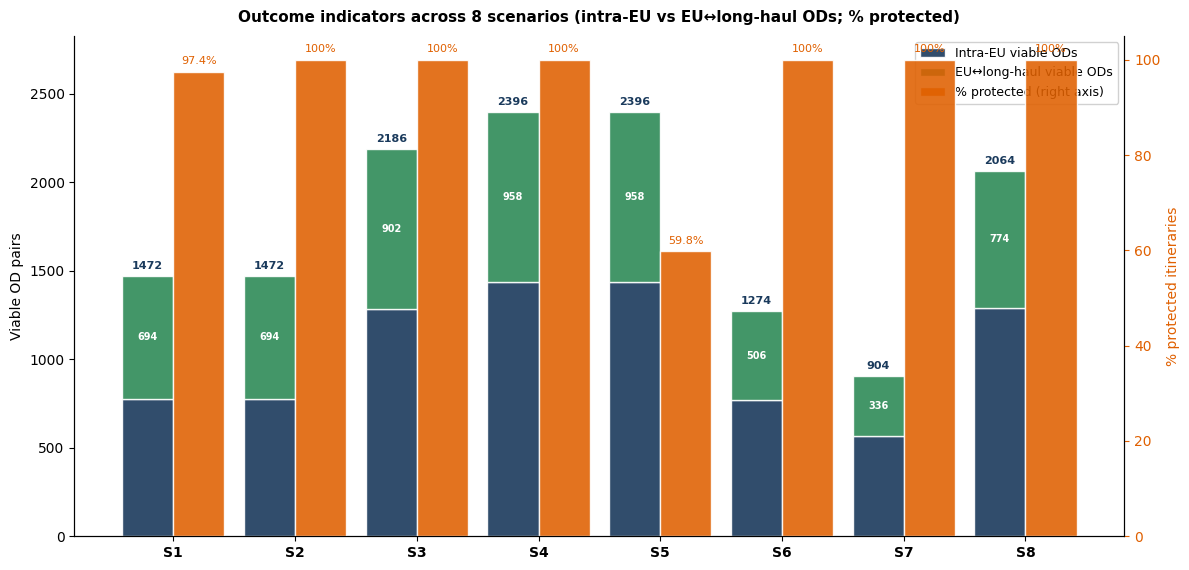

Bar chart saved to figures/scenario_outcomes.{pdf,png}


In [16]:
# ── 4.1  Stacked bar chart: viable ODs (intra-EU + EU↔LH) and % protected ─────

scenario_codes = [s[0].split(':')[0] for s in SCENARIOS]
intra_vals     = [raw_results[s[0]]['viable_OD_intra_eu'] for s in SCENARIOS]
eulh_vals      = [raw_results[s[0]]['viable_OD_eu_to_lh'] for s in SCENARIOS]
protected_vals = [raw_results[s[0]]['pct_protected']      for s in SCENARIOS]

x = np.arange(len(scenario_codes))
width = 0.42

fig, ax_left = plt.subplots(figsize=(12, 5.8))
ax_right = ax_left.twinx()

bars_intra = ax_left.bar(x - width/2, intra_vals, width,
                         color='#1a3a5c', alpha=0.9, edgecolor='white',
                         label='Intra-EU viable ODs')
bars_eulh  = ax_left.bar(x - width/2, eulh_vals, width,
                         bottom=intra_vals,
                         color='#2e8b57', alpha=0.9, edgecolor='white',
                         label='EU↔long-haul viable ODs')
bars_prot  = ax_right.bar(x + width/2, protected_vals, width,
                          color='#e06000', alpha=0.88, edgecolor='white',
                          label='% protected')

ax_left.set_xticks(x)
ax_left.set_xticklabels(scenario_codes, fontsize=10, fontweight='bold')
ax_left.set_ylabel('Viable OD pairs', fontsize=10)
ax_right.set_ylabel('% protected itineraries', color='#e06000', fontsize=10)
ax_right.tick_params(axis='y', colors='#e06000')
ax_right.set_ylim(0, 105)
totals = [a + b for a, b in zip(intra_vals, eulh_vals)]
ax_left.set_ylim(0, max(totals) * 1.18)

# Total label above each stack
for xi, total, eu in zip(x, totals, eulh_vals):
    ax_left.text(xi - width/2, total + max(totals)*0.012,
                 f'{total}', ha='center', va='bottom',
                 fontsize=8, color='#1a3a5c', fontweight='bold')
    if eu > 0:
        ax_left.text(xi - width/2, total - eu/2,
                     f'{eu}', ha='center', va='center',
                     fontsize=7, color='white', fontweight='bold')
for b, v in zip(bars_prot, protected_vals):
    ax_right.text(b.get_x() + b.get_width()/2, b.get_height() + 1.2,
                  f'{v:g}%', ha='center', va='bottom',
                  fontsize=8, color='#e06000')

ax_left.spines[['top']].set_visible(False)
ax_right.spines[['top']].set_visible(False)
ax_left.set_title('Outcome indicators across 8 scenarios '
                  '(intra-EU vs EU↔long-haul ODs; % protected)',
                  fontsize=11, fontweight='bold', pad=10)

handles = [bars_intra, bars_eulh, bars_prot]
labels  = ['Intra-EU viable ODs', 'EU↔long-haul viable ODs',
           '% protected (right axis)']
ax_left.legend(handles, labels, loc='upper right',
               fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(FIGURES / 'scenario_outcomes.pdf', dpi=150, bbox_inches='tight')
plt.savefig(FIGURES / 'scenario_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar chart saved to figures/scenario_outcomes.{pdf,png}')

---
## Part 5 — Thesis-ready results table

In [17]:
# ── 5.1  Export results table to CSV ─────────────────────────────────────────

df.to_csv(FIGURES / 'scenario_results.csv')
print('Results table saved to figures/scenario_results.csv')

summary_cols = [
    'Viable OD pairs', 'Intra-EU ODs', 'EU→LH ODs',
    'Avg options / OD', '% protected', '% thin covered',
]
print('\n=== Key outcome indicators by scenario ===')
print(df[summary_cols].to_string())

Results table saved to figures/scenario_results.csv

=== Key outcome indicators by scenario ===
                                  Viable OD pairs  Intra-EU ODs  EU→LH ODs  Avg options / OD  % protected  % thin covered
Scenario                                                                                                                 
S1: NWC, alliance, 4 anch                    1472           778        694              1.36         97.4            27.3
S2: NWC, platform, 4 anch                    1472           778        694              1.36        100.0            27.3
S3: +REG, platform, 4 anch                   2186          1284        902              1.39        100.0            47.4
S4: Full open, platform, 4 anch              2396          1438        958              1.81        100.0            53.0
S5: Full open, alliance, 4 anch              2396          1438        958              1.81         59.8            53.0
S6: Full open, platform, 2 anch              1274 

In [18]:
# ── 5.2  Effect decomposition: pairwise marginal contributions ────────────────

comparisons = [
    ('Effect of platform scope (NWC-only)',
     'S1: NWC, alliance, 4 anch',
     'S2: NWC, platform, 4 anch'),
    ('Effect of adding regionals',
     'S2: NWC, platform, 4 anch',
     'S3: +REG, platform, 4 anch'),
    ('Effect of adding LCCs (full open)',
     'S3: +REG, platform, 4 anch',
     'S4: Full open, platform, 4 anch'),
    ('Effect of scope: platform → alliance (full open)',
     'S4: Full open, platform, 4 anch',
     'S5: Full open, alliance, 4 anch'),
    ('Effect of anchor NWCs 4→2',
     'S4: Full open, platform, 4 anch',
     'S6: Full open, platform, 2 anch'),
    ('Effect of anchor NWCs 2→1',
     'S6: Full open, platform, 2 anch',
     'S7: Full open, platform, 1 anch'),
    ('Effect of dropping FRA hub',
     'S4: Full open, platform, 4 anch',
     'S8: Full open, platform, FRA off'),
]

header = (f'{"Comparison":<50} {"ΔIntra-EU":>10} '
          f'{"ΔEU→LH":>10} {"Δ% prot":>10} {"Δ% thin":>10}')
print(header)
print('-' * len(header))

def fmt(x):
    return f'+{x:.1f}' if x >= 0 else f'{x:.1f}'

for label, s_before, s_after in comparisons:
    a, b = raw_results[s_before], raw_results[s_after]
    d_intra = b['viable_OD_intra_eu']  - a['viable_OD_intra_eu']
    d_eulh  = b['viable_OD_eu_to_lh']  - a['viable_OD_eu_to_lh']
    d_prot  = b['pct_protected']       - a['pct_protected']
    d_thin  = b['pct_thin_covered']    - a['pct_thin_covered']
    print(f'{label:<50} {fmt(d_intra):>10} {fmt(d_eulh):>10} '
          f'{fmt(d_prot):>10}% {fmt(d_thin):>10}%')


Comparison                                          ΔIntra-EU     ΔEU→LH    Δ% prot    Δ% thin
----------------------------------------------------------------------------------------------
Effect of platform scope (NWC-only)                      +0.0       +0.0       +2.6%       +0.0%
Effect of adding regionals                             +506.0     +208.0       +0.0%      +20.1%
Effect of adding LCCs (full open)                      +154.0      +56.0       +0.0%       +5.6%
Effect of scope: platform → alliance (full open)         +0.0       +0.0      -40.2%       +0.0%
Effect of anchor NWCs 4→2                              -670.0     -452.0       +0.0%      -26.4%
Effect of anchor NWCs 2→1                              -200.0     -170.0       +0.0%       -6.9%
Effect of dropping FRA hub                             -148.0     -184.0       +0.0%       -6.1%


In [19]:
# ── 5.3  List output files ────────────────────────────────────────────────────

print('Output files in figures/:')
for f in sorted(FIGURES.iterdir()):
    print(f'  {f.name}')

Output files in figures/:
  scenario_outcomes.pdf
  scenario_outcomes.png
  scenario_results.csv
